In [1]:
#! Imports, seed and Google Drive paths
import hashlib
import json
import os
import random
import sys
import time

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from google.colab import drive
from IPython.display import display
from torchvision import models

drive.mount('/content/drive')
SEED = 6304
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False

ROOT = Path('/content/drive/MyDrive/pa1-beyond-iid')

PACS_DIR = ROOT / 'data/pacs'
SHARED_DIR = ROOT / 'shared'
TASK2_DIR = ROOT / 'task2'
MODEL_DIR = TASK2_DIR / 'models'
METHOD_DIR = TASK2_DIR / 'methods'
CONFIG_DIR = TASK2_DIR / 'configs'
RESULT_DIR = TASK2_DIR / 'results/cdan'
SPLIT_FILE = SHARED_DIR / 'splits/pacs_sketch_seed6304.json'
BASE_PATH = CONFIG_DIR / 'base.json'
SOURCE_RUN_PATH = CONFIG_DIR / 'source_only.json'
INITIAL_PATH = MODEL_DIR / 'resnet18_initial_seed6304.pt'
BEST_PATH = MODEL_DIR / 'cdan_best.pt'
LAST_PATH = MODEL_DIR / 'cdan_last.pt'
RUN_CONFIG_PATH = CONFIG_DIR / 'cdan.json'

for folder in [METHOD_DIR, RESULT_DIR, MODEL_DIR, CONFIG_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

required_setup = [PACS_DIR / 'pacs_sources.tar', PACS_DIR / 'pacs_target_unlabeled.tar',
                  PACS_DIR / 'source_train.csv', PACS_DIR / 'source_val.csv',
                  PACS_DIR / 'target_unlabeled.csv', SHARED_DIR / 'pacs.py',
                  SHARED_DIR / 'pacs_training.py', BASE_PATH, SPLIT_FILE,
                  SOURCE_RUN_PATH, INITIAL_PATH]

missing = [str(path) for path in required_setup if not path.is_file()]

if missing:
    raise FileNotFoundError('Finish Task 2A and Task 2B setup first: ' + str(missing))

def file_sha256(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as file:
        for block in iter(lambda: file.read(4 * 1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

with open(BASE_PATH) as file:
    base = json.load(file)

with open(SPLIT_FILE) as file:
    shared_split = json.load(file)

with open(SOURCE_RUN_PATH) as file:
    erm_config = json.load(file)

SOURCE_DOMAINS = ['photo', 'art_painting', 'cartoon']
LABEL_NAMES = base['class_names']

if (base['seed'] != SEED or shared_split['seed'] != SEED
        or base['source_domains'] != SOURCE_DOMAINS
        or base['target_domain'] != 'sketch' or len(LABEL_NAMES) != 7
        or erm_config['base_config_sha256'] != file_sha256(BASE_PATH)
        or erm_config['source_split_sha256'] != file_sha256(SPLIT_FILE)):
    raise ValueError('Task 2A/2B locked protocol disagrees with Task 2E')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Device:', DEVICE, '| T4 GPU recommended')
print('Reusing the exact initial checkpoint:', INITIAL_PATH)
print('Target class labels are never read by this notebook.')

Mounted at /content/drive
Device: cuda | T4 GPU recommended
Reusing the exact initial checkpoint: /content/drive/MyDrive/pa1-beyond-iid/task2/models/resnet18_initial_seed6304.pt
Target class labels are never read by this notebook.


In [2]:
#! Source and target dataset loaders; enforce label-free target access
sys.path.insert(0, str(SHARED_DIR))

from pacs import make_loaders, set_seed, freeze_bn_running_stats
from pacs_training import evaluate_sources, atomic_torch_save, cpu_state_dict

LOCAL_ROOT = Path('/content/pacs_task2_adaptation')
source_loaders, val_loaders, target_loader = make_loaders(
    PACS_DIR, LOCAL_ROOT, include_target=True, workers=2
)

source_train = pd.read_csv(PACS_DIR / 'source_train.csv')
source_val = pd.read_csv(PACS_DIR / 'source_val.csv')

target_manifest = pd.read_csv(PACS_DIR / 'target_unlabeled.csv')

if set(source_train['hf_index']) & set(source_val['hf_index']):
    raise ValueError('Source training and validation indices overlap')

if {'label', 'label_name'} & set(target_manifest.columns):
    raise ValueError('Target manifest must not contain class labels')

if not target_loader.dataset.unlabeled:
    raise RuntimeError('Target loader is not configured as unlabeled')

for domain in SOURCE_DOMAINS:
    print(domain, '| train', len(source_loaders[domain].dataset),
          '| val', len(val_loaders[domain].dataset),
          '| batches', len(source_loaders[domain]))

print('Sketch unlabeled:', len(target_loader.dataset), '| 24-image batches:', len(target_loader))

STEPS_PER_EPOCH = max(len(source_loaders[domain]) for domain in SOURCE_DOMAINS)

if min(len(loader) for loader in source_loaders.values()) == 0 or len(target_loader) == 0:
    raise ValueError('At least one loader has no full batch')

if STEPS_PER_EPOCH != erm_config['steps_per_source_epoch']:
    raise RuntimeError('Different source epoch length than Source-only ERM')

print('Updates per source epoch:', STEPS_PER_EPOCH)
print('Batch: 8 Photo + 8 Art + 8 Cartoon + 24 unlabeled Sketch = 48.')

photo | train 1336 | val 334 | batches 167
art_painting | train 1638 | val 410 | batches 204
cartoon | train 1875 | val 469 | batches 234
Sketch unlabeled: 3929 | 24-image batches: 163
Updates per source epoch: 234
Batch: 8 Photo + 8 Art + 8 Cartoon + 24 unlabeled Sketch = 48.


In [3]:
#! Restore initial backbone/head without accidentally loading ERM trained weights
set_seed(SEED)

initial = torch.load(INITIAL_PATH, map_location='cpu', weights_only=True)
INITIAL_SHA = file_sha256(INITIAL_PATH)

if initial['seed'] != SEED or initial['class_names'] != LABEL_NAMES:
    raise ValueError('Shared initialization is incompatible with PACS protocol')

if erm_config['initial_checkpoint_sha256'] != INITIAL_SHA:
    raise RuntimeError('Task 2B and DAN initial checkpoints differ')

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 7)
model.load_state_dict(initial['model_state_dict'], strict=True)
BN_REFERENCE = {name: tensor.detach().cpu().clone()
                for name, tensor in initial['model_state_dict'].items()
                if name.endswith(('running_mean', 'running_var', 'num_batches_tracked'))}

model = model.to(DEVICE)

print('Restored shared initial weights (not ERM best).')
print('Initial SHA-256:', INITIAL_SHA)
print('Feature dimensions:', model.fc.in_features)
print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))

Restored shared initial weights (not ERM best).
Initial SHA-256: b7a7953b493b6a3b5e6ae577ed139bc7f99da62686a5a4af523fd72def8a5e07
Feature dimensions: 512
Trainable parameters: 11180103


In [4]:
#! Reuse shared adaptation code verbatim and persist the CDAN method

ADAPTATION_MODULE = "#! Shared adaptation loop for PACS: reused by DAN, DANN and CDAN\nfrom contextlib import nullcontext\n\nimport torch\n\nfrom pacs import SOURCE_DOMAINS, freeze_bn_running_stats\nfrom pacs_training import set_epoch_loaders\n\n\ndef forward_features_logits(model, images):\n    #! Exactly torchvision ResNet-18's forward, exposing its 512-D pooled features.\n    x = model.conv1(images)\n    x = model.bn1(x)\n    x = model.relu(x)\n    x = model.maxpool(x)\n    x = model.layer1(x)\n    x = model.layer2(x)\n    x = model.layer3(x)\n    x = model.layer4(x)\n    features = torch.flatten(model.avgpool(x), 1)\n    return features, model.fc(features)\n\n\ndef _take_next(iterator, loader):\n    try:\n        return next(iterator), iterator\n    except StopIteration:\n        iterator = iter(loader)\n        return next(iterator), iterator\n\n\ndef train_adaptation_epoch(model, source_loaders, target_loader, optimizer, device,\n                           epoch, objective, scaler=None, seed=6304, extra_module=None):\n    #! Identical source batching and source-epoch definition to Source-only ERM.\n    model.train()\n    freeze_bn_running_stats(model)\n    if extra_module is not None:\n        extra_module.train()\n    set_epoch_loaders(source_loaders, epoch, seed)\n    target_loader.generator.manual_seed(seed + epoch * 1000 + len(SOURCE_DOMAINS))\n\n    source_iters = {domain: iter(source_loaders[domain]) for domain in SOURCE_DOMAINS}\n    target_iter = iter(target_loader)\n    steps = max(len(source_loaders[domain]) for domain in SOURCE_DOMAINS)\n    if steps == 0 or len(target_loader) == 0:\n        raise ValueError('Training requires nonempty full source and target batches')\n\n    sums = {'train_total_loss': 0., 'train_cls_loss': 0., 'train_alignment_loss': 0.}\n    correct, count = 0, 0\n    per_domain_correct = {d: 0 for d in SOURCE_DOMAINS}\n    per_domain_count = {d: 0 for d in SOURCE_DOMAINS}\n    amp_enabled = device.type == 'cuda' and scaler is not None and scaler.is_enabled()\n\n    for step in range(steps):\n        batches = []\n        for domain in SOURCE_DOMAINS:\n            batch, source_iters[domain] = _take_next(source_iters[domain], source_loaders[domain])\n            batches.append(batch)\n        target_batch, target_iter = _take_next(target_iter, target_loader)\n        #! The target loader returns images only; it contains no class labels.\n        if not isinstance(target_batch, torch.Tensor):\n            raise TypeError('Unlabeled Sketch loader must return image tensors only')\n\n        source_images = torch.cat([batch[0] for batch in batches], dim=0).to(device, non_blocking=True)\n        labels = torch.cat([batch[1] for batch in batches], dim=0).to(device, non_blocking=True)\n        target_images = target_batch.to(device, non_blocking=True)\n        if len(source_images) != 24 or len(target_images) != 24:\n            raise ValueError('Expected 8 samples from each source and 24 unlabeled target samples')\n        images = torch.cat((source_images, target_images), dim=0)\n        optimizer.zero_grad(set_to_none=True)\n        context = torch.autocast('cuda', dtype=torch.float16) if amp_enabled else nullcontext()\n        with context:\n            features, logits = forward_features_logits(model, images)\n            total_loss, components = objective(features[:24], logits[:24], labels,\n                                               features[24:], logits[24:], step, steps)\n\n        if not bool(torch.isfinite(total_loss).item()):\n            raise FloatingPointError('Non-finite adaptation loss; inspect this batch and the MMD kernel')\n        if amp_enabled:\n            scaler.scale(total_loss).backward()\n            scaler.step(optimizer)\n            scaler.update()\n        else:\n            total_loss.backward()\n            optimizer.step()\n\n        sums['train_total_loss'] += float(total_loss.detach())\n        sums['train_cls_loss'] += float(components['classification'].detach())\n        sums['train_alignment_loss'] += float(components['alignment'].detach())\n        preds = logits[:24].detach().argmax(1)\n        correct += int((preds == labels).sum().item())\n        count += len(labels)\n        for index, domain in enumerate(SOURCE_DOMAINS):\n            start = index * 8\n            per_domain_correct[domain] += int((preds[start:start+8] == labels[start:start+8]).sum().item())\n            per_domain_count[domain] += 8\n\n    result = {name: value / steps for name, value in sums.items()}\n    result.update({'train_accuracy': correct / count, 'updates': steps,\n                   'source_examples_processed': count, 'target_examples_processed': 24 * steps})\n    result.update({f'train_{domain}_accuracy': per_domain_correct[domain] / per_domain_count[domain]\n                   for domain in SOURCE_DOMAINS})\n    return result\n"
CDAN_MODULE = "#! Conditional adversarial network: full multilinear feature-class interaction\nimport torch\nfrom torch import nn\nimport torch.nn.functional as F\n\n\nclass ReverseGradient(torch.autograd.Function):\n    @staticmethod\n    def forward(ctx, x, alpha):\n        #! Forward identity; reverse only the gradient into features AND probabilities.\n        ctx.alpha = float(alpha)\n        return x.view_as(x)\n\n    @staticmethod\n    def backward(ctx, gradient):\n        return -ctx.alpha * gradient, None\n\n\ndef reverse_gradient(x, alpha):\n    return ReverseGradient.apply(x, alpha)\n\n\ndef conditional_representation(features, logits):\n    #! Full outer product: batch x 512 x 7 -> batch x 3584. NO detach on either path.\n    if features.ndim != 2 or features.shape[1] != 512:\n        raise ValueError('CDAN expects ResNet-18 pre-classifier features [N,512]')\n    if logits.ndim != 2 or logits.shape != (features.shape[0], 7):\n        raise ValueError('CDAN expects seven-class logits for every feature vector')\n    probabilities = F.softmax(logits.float(), dim=1)\n    return torch.bmm(features.float().unsqueeze(2), probabilities.unsqueeze(1)).flatten(1)\n\n\nclass DomainDiscriminator(nn.Module):\n    def __init__(self):\n        super().__init__()\n        self.network = nn.Sequential(\n            nn.Linear(512 * 7, 256),\n            nn.ReLU(),\n            nn.Dropout(p=0.5),\n            nn.Linear(256, 2),\n        )\n\n    def forward(self, conditional_features):\n        return self.network(conditional_features)\n\n\ndef cdan_objective(source_features, source_logits, source_labels,\n                   target_features, target_logits, step, steps,\n                   discriminator, alpha, domain_weight=1.0):\n    #! Source CE only; target logits supply soft class predictions, NEVER labels.\n    cls_loss = F.cross_entropy(source_logits, source_labels)\n    source_conditional = conditional_representation(source_features, source_logits)\n    target_conditional = conditional_representation(target_features, target_logits)\n    combined = torch.cat((source_conditional, target_conditional), dim=0)\n    domain_logits = discriminator(reverse_gradient(combined, alpha))\n    domain_labels = torch.cat((\n        torch.zeros(len(source_features), dtype=torch.long, device=combined.device),\n        torch.ones(len(target_features), dtype=torch.long, device=combined.device),\n    ))\n    #! NO entropy weights, confidence filters, or extra conditioning variants.\n    domain_loss = F.cross_entropy(domain_logits, domain_labels)\n    domain_accuracy = (domain_logits.detach().argmax(1) == domain_labels).float().mean()\n    return cls_loss + domain_weight * domain_loss, {\n        'classification': cls_loss,\n        'alignment': domain_loss,\n        'domain_accuracy': domain_accuracy,\n    }\n"
ADAPTATION_FILE = SHARED_DIR / 'pacs_adaptation_cdan.py'
CDAN_FILE = METHOD_DIR / 'cdan.py'

for path, contents in [(ADAPTATION_FILE, ADAPTATION_MODULE), (CDAN_FILE, CDAN_MODULE)]:
    if path.is_file() and path.read_text() != contents:
        raise RuntimeError('Existing module differs; inspect rather than overwriting: ' + str(path))

    if not path.is_file():
        path.write_text(contents)

    print('Module:', path)

from pacs_adaptation_cdan import forward_features_logits, train_adaptation_epoch
sys.path.insert(0, str(METHOD_DIR))
from cdan import (DomainDiscriminator, reverse_gradient,
                  conditional_representation, cdan_objective)

#! Check custom ResNet feature path against torchvision's own forward
model.eval()
tiny = torch.randn(2, 3, 64, 64, device=DEVICE)

with torch.inference_mode():
    features, extracted_logits = forward_features_logits(model, tiny)
    official_logits = model(tiny)

if features.shape != (2, 512) or not torch.allclose(extracted_logits, official_logits, atol=1e-5):
    raise RuntimeError('Custom ResNet feature path disagrees with torchvision')

del tiny, features, extracted_logits, official_logits

#! Gradient reversal changes gradient sign and magnitude but not forward output
x = torch.tensor([1., -2., 3.], requires_grad=True)
y = reverse_gradient(x, 0.4)

if not torch.equal(x, y):
    raise RuntimeError('Gradient reversal changed its forward input')

y.sum().backward()

if not torch.allclose(x.grad, torch.full_like(x, -0.4), atol=1e-7):
    raise RuntimeError('Gradient reversal test failed')

#! Initialize only the new discriminator; the pretrained model stays unchanged
set_seed(SEED + 1)
discriminator = DomainDiscriminator().to(DEVICE)
source_features = torch.randn(8, 512, device=DEVICE, requires_grad=True)
target_features = torch.randn(8, 512, device=DEVICE, requires_grad=True)
source_logits = torch.randn(8, 7, device=DEVICE, requires_grad=True)
target_logits = torch.randn(8, 7, device=DEVICE, requires_grad=True)
conditional = conditional_representation(source_features, source_logits)

if conditional.shape != (8, 3584):
    raise RuntimeError('CDAN full outer product must be [batch, 3584]')

loss, diagnostic = cdan_objective(source_features, source_logits,
                                 torch.arange(8, device=DEVICE) % 7,
                                 target_features, target_logits, 0, 1,
                                 discriminator, alpha=0.5)
loss.backward()

if (source_features.grad is None or target_features.grad is None
        or source_logits.grad is None or target_logits.grad is None
        or not all(param.grad is not None for param in discriminator.parameters())
        or not bool(torch.isfinite(loss))):
    raise RuntimeError('CDAN must propagate gradients into f, p and discriminator')

if target_logits.grad.abs().sum().item() == 0:
    raise RuntimeError('Target class-probability path was detached')

discriminator.zero_grad(set_to_none=True)

del source_features, target_features, source_logits, target_logits, conditional, loss, diagnostic

print('ResNet equivalence, 3584-D conditioning, differentiable f/p and GRL: PASS')

Module: /content/drive/MyDrive/pa1-beyond-iid/shared/pacs_adaptation_cdan.py
Module: /content/drive/MyDrive/pa1-beyond-iid/task2/methods/cdan.py
ResNet equivalence, 3584-D conditioning, differentiable f/p and GRL: PASS


In [5]:
#! Lock source/target protocol and construct joint optimizer
DOMAIN_LOSS_WEIGHT = 1.0
MAX_EPOCHS = 30
PATIENCE = 5

RUN_CONFIG = {
    'method': 'cdan', 'seed': SEED,
    'base_config_sha256': file_sha256(BASE_PATH),
    'source_split_sha256': file_sha256(SPLIT_FILE),
    'source_train_manifest_sha256': file_sha256(PACS_DIR / 'source_train.csv'),
    'source_val_manifest_sha256': file_sha256(PACS_DIR / 'source_val.csv'),
    'target_unlabeled_manifest_sha256': file_sha256(PACS_DIR / 'target_unlabeled.csv'),
    'initial_checkpoint_sha256': INITIAL_SHA,
    'source_only_config_sha256': file_sha256(SOURCE_RUN_PATH),
    'shared_training_module_sha256': file_sha256(SHARED_DIR / 'pacs_training.py'),
    'adaptation_module_sha256': file_sha256(ADAPTATION_FILE),
    'cdan_module_sha256': file_sha256(CDAN_FILE),
    'source_domains': SOURCE_DOMAINS, 'target_domain': 'sketch',
    'train_batch_per_source': 8, 'train_batch_target': 24,
    'steps_per_source_epoch': STEPS_PER_EPOCH,
    'epoch_definition': 'longest source loader once; cycle shorter sources and target',
    'backbone': 'ImageNet ResNet-18 V1, fully fine-tuned, 512-D pre-head features',
    'discriminator': '3584 -> 256 -> ReLU -> Dropout(0.5) -> 2',
    'discriminator_seed': SEED + 1,
    'conditional_input': 'vec(f outer softmax(class_logits)), 512*7 = 3584',
    'f_detached': False,
    'p_detached': False,
    'entropy_conditioning': False,
    'domain_labels': {'source': 0, 'target': 1},
    'domain_loss': 'binary-domain cross entropy across equal 24:24 source-target batch',
    'domain_loss_weight': DOMAIN_LOSS_WEIGHT,
    'gradient_reversal': 'identity forward, -alpha gradient to both f and p; no reversal on discriminator',
    'grl_alpha': '2/(1+exp(-10*p))-1',
    'progress': 'p=((epoch-1)*steps + step)/(30*steps-1), step starts at zero',
    'optimizer': 'AdamW for backbone/classifier and domain discriminator together',
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,
    'max_epochs': MAX_EPOCHS,
    'patience': PATIENCE,
    'checkpoint_selection': 'unweighted_mean_source_validation_macro_f1',
    'batchnorm': 'pretrained running statistics frozen; affine parameters trainable',
    'target_class_labels_used': False,
    'target_evaluation': 'deferred until all Task 2 methods and checkpoints are fixed',
}

if RUN_CONFIG_PATH.is_file():
    if json.loads(RUN_CONFIG_PATH.read_text()) != RUN_CONFIG:
        raise RuntimeError('An existing CDAN configuration differs. Do not overwrite it.')
else:
    RUN_CONFIG_PATH.write_text(json.dumps(RUN_CONFIG, indent=2))

RUN_SHA = file_sha256(RUN_CONFIG_PATH)

optimizer = torch.optim.AdamW(list(model.parameters()) + list(discriminator.parameters()),
                               lr=1e-4, weight_decay=1e-4)
scaler = torch.amp.GradScaler('cuda', enabled=False)

history = []
best_f1, best_epoch, bad_epochs, start_epoch = -1.0, 0, 0, 1

training_finished = False

if LAST_PATH.is_file():
    last = torch.load(LAST_PATH, map_location='cpu', weights_only=True)

    if last['run_config_sha256'] != RUN_SHA:
        raise RuntimeError('Previous CDAN run has a different locked configuration')

    model.load_state_dict(last['model_state_dict'], strict=True)

    discriminator.load_state_dict(last['discriminator_state_dict'], strict=True)
    optimizer.load_state_dict(last['optimizer_state_dict'])

    scaler.load_state_dict(last['scaler_state_dict'])

    history = last['history']

    best_f1, best_epoch, bad_epochs = last['best_f1'], last['best_epoch'], last['bad_epochs']

    start_epoch, training_finished = last['epoch'] + 1, last['finished']

    if not BEST_PATH.is_file():
        raise FileNotFoundError('Resume checkpoint exists but CDAN best weights are missing')

    #! Restore dropout/random augmentation sequences on resumed sessions.
    random.setstate(last['python_rng_state'])
    np.random.set_state((last['numpy_rng_state'][0],
                         np.array(last['numpy_rng_state'][1], dtype=np.uint32),
                         last['numpy_rng_state'][2], last['numpy_rng_state'][3],
                         last['numpy_rng_state'][4]))

    torch.set_rng_state(last['torch_rng_state'])

    if DEVICE.type == 'cuda' and last.get('cuda_rng_state') is not None:
        torch.cuda.set_rng_state_all(last['cuda_rng_state'])

    print('Resuming after epoch:', last['epoch'], '| finished:', training_finished)
else:
    if BEST_PATH.is_file():
        raise RuntimeError('Best checkpoint exists without resume checkpoint. Investigate first.')

    print('New CDAN run from the same model initial weights as ERM and DAN.')

print('Locked configuration:', RUN_CONFIG_PATH)
print('Next epoch:', start_epoch)

New CDAN run from the same model initial weights as ERM and DAN.
Locked configuration: /content/drive/MyDrive/pa1-beyond-iid/task2/configs/cdan.json
Next epoch: 1


In [6]:
#! Fine-tune with source CE + unit-weight domain CE, scheduled GRL
import math

def grl_strength(epoch, step, steps, max_epochs=MAX_EPOCHS):
    #! Pre-set full budget, not the unknown early-stopping epoch.
    total_updates = max_epochs * steps

    progress = ((epoch - 1) * steps + step) / max(1, total_updates - 1)
    progress = max(0.0, min(1.0, progress))

    return 2.0 / (1.0 + math.exp(-10.0 * progress)) - 1.0

current_epoch = start_epoch
batch_diagnostics = []

def objective(source_features, source_logits, source_labels,
              target_features, target_logits, step, steps):
    alpha = grl_strength(current_epoch, step, steps)

    loss, parts = cdan_objective(source_features, source_logits, source_labels,
                                 target_features, target_logits, step, steps,
                                 discriminator=discriminator, alpha=alpha,
                                 domain_weight=DOMAIN_LOSS_WEIGHT)

    batch_diagnostics.append((alpha, float(parts['domain_accuracy'].detach())))

    return loss, parts

if training_finished:
    print('CDAN already completed; no retraining.')
else:
    for epoch in range(start_epoch, MAX_EPOCHS + 1):
        start_time = time.perf_counter()

        current_epoch = epoch

        batch_diagnostics = []

        train_metrics = train_adaptation_epoch(
            model, source_loaders, target_loader, optimizer, DEVICE,
            epoch=epoch, objective=objective, scaler=scaler, seed=SEED,
            extra_module=discriminator
        )

        source_val = evaluate_sources(model, val_loaders, DEVICE, num_classes=7)

        score = source_val['mean_macro_f1']

        improved = score > best_f1 + 1e-8

        if improved:
            best_f1, best_epoch, bad_epochs = score, epoch, 0

            atomic_torch_save({
                'method': 'cdan', 'seed': SEED, 'epoch': epoch,
                'best_source_val_mean_macro_f1': best_f1,
                'source_validation': source_val,
                'run_config_sha256': RUN_SHA,
                'initial_checkpoint_sha256': INITIAL_SHA,
                'class_names': LABEL_NAMES,
                'model_state_dict': cpu_state_dict(model),
                'discriminator_state_dict': cpu_state_dict(discriminator),
            }, BEST_PATH)
        else:
            bad_epochs += 1

        row = {
            'epoch': epoch, **train_metrics,
            'mean_domain_accuracy': float(np.mean([item[1] for item in batch_diagnostics])),
            'mean_grl_alpha': float(np.mean([item[0] for item in batch_diagnostics])),
            'first_grl_alpha': batch_diagnostics[0][0],
            'last_grl_alpha': batch_diagnostics[-1][0],
            'mean_source_val_accuracy': source_val['mean_accuracy'],
            'mean_source_val_macro_f1': source_val['mean_macro_f1'],
            'worst_source_val_macro_f1': source_val['worst_source_macro_f1'],
            'elapsed_seconds': time.perf_counter() - start_time,
        }

        for domain in SOURCE_DOMAINS:
            row[f'val_{domain}_accuracy'] = source_val[domain]['accuracy']
            row[f'val_{domain}_macro_f1'] = source_val[domain]['macro_f1']
            row[f'val_{domain}_loss'] = source_val[domain]['loss']

        history.append(row)
        training_finished = bad_epochs >= PATIENCE or epoch == MAX_EPOCHS

        atomic_torch_save({
            'epoch': epoch, 'finished': training_finished,
            'model_state_dict': cpu_state_dict(model),
            'discriminator_state_dict': cpu_state_dict(discriminator),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'python_rng_state': random.getstate(),
            'numpy_rng_state': [np.random.get_state()[0], np.random.get_state()[1].tolist(),
                                np.random.get_state()[2], np.random.get_state()[3], np.random.get_state()[4]],
            'torch_rng_state': torch.get_rng_state(),
            'cuda_rng_state': torch.cuda.get_rng_state_all() if DEVICE.type == 'cuda' else None,
            'history': history, 'best_epoch': best_epoch, 'best_f1': best_f1,
            'bad_epochs': bad_epochs, 'run_config_sha256': RUN_SHA,
        }, LAST_PATH)

        pd.DataFrame(history).to_csv(RESULT_DIR / 'history.csv', index=False)

        print(f"Epoch {epoch:02d} | cls CE {row['train_cls_loss']:.4f} | "
              f"domain CE {row['train_alignment_loss']:.4f} | "
              f"domain acc {row['mean_domain_accuracy']:.3f} | "
              f"alpha {row['first_grl_alpha']:.3f}–{row['last_grl_alpha']:.3f} | "
              f"source val F1 {score:.4f} | best {best_f1:.4f} "
              f"(epoch {best_epoch}) | no improvement {bad_epochs}/{PATIENCE}")

        if training_finished:
            break

print('Training complete:', training_finished, '| best epoch:', best_epoch,
      '| best source validation F1:', round(best_f1, 5))

Epoch 01 | cls CE 13.1382 | domain CE 160.4748 | domain acc 0.711 | alpha 0.000–0.164 | source val F1 0.0382 | best 0.0382 (epoch 1) | no improvement 0/5
Epoch 02 | cls CE 2.6543 | domain CE 0.7098 | domain acc 0.786 | alpha 0.165–0.321 | source val F1 0.1818 | best 0.1818 (epoch 2) | no improvement 0/5
Epoch 03 | cls CE 1.8438 | domain CE 0.4516 | domain acc 0.814 | alpha 0.322–0.462 | source val F1 0.2158 | best 0.2158 (epoch 3) | no improvement 0/5
Epoch 04 | cls CE 579.9362 | domain CE 595.2700 | domain acc 0.515 | alpha 0.462–0.582 | source val F1 0.0394 | best 0.2158 (epoch 3) | no improvement 1/5
Epoch 05 | cls CE 1.9175 | domain CE 0.6936 | domain acc 0.496 | alpha 0.583–0.682 | source val F1 0.0507 | best 0.2158 (epoch 3) | no improvement 2/5
Epoch 06 | cls CE 1.9157 | domain CE 0.6932 | domain acc 0.497 | alpha 0.682–0.761 | source val F1 0.0507 | best 0.2158 (epoch 3) | no improvement 3/5
Epoch 07 | cls CE 1.9110 | domain CE 0.6932 | domain acc 0.494 | alpha 0.762–0.823 | so

In [7]:
#! Evaluate source-selected CDAN model and save metrics
if not training_finished or not BEST_PATH.is_file():
    raise RuntimeError('Complete CDAN training first')

best = torch.load(BEST_PATH, map_location='cpu', weights_only=True)

if best['run_config_sha256'] != RUN_SHA or best['initial_checkpoint_sha256'] != INITIAL_SHA:
    raise RuntimeError('Best CDAN weights belong to another protocol')

model.load_state_dict(best['model_state_dict'], strict=True)

discriminator.load_state_dict(best['discriminator_state_dict'], strict=True)
validation = evaluate_sources(model, val_loaders, DEVICE, num_classes=7)

rows = [{'domain': domain, **validation[domain]} for domain in SOURCE_DOMAINS]
rows += [
    {'domain': 'mean', 'accuracy': validation['mean_accuracy'],
     'macro_f1': validation['mean_macro_f1'], 'loss': None, 'n_images': None},
    {'domain': 'worst', 'accuracy': validation['worst_source_accuracy'],
     'macro_f1': validation['worst_source_macro_f1'], 'loss': None, 'n_images': None},
]

val_table = pd.DataFrame(rows)
val_table.to_csv(RESULT_DIR / 'source_validation.csv', index=False)

summary = {
    'method': 'cdan', 'seed': SEED, 'domain_loss_weight': DOMAIN_LOSS_WEIGHT,
    'grl_schedule': RUN_CONFIG['grl_alpha'], 'best_epoch': best['epoch'],
    'best_source_validation_macro_f1': best['best_source_val_mean_macro_f1'],
    'source_validation': validation,
    'checkpoint_path': str(BEST_PATH),
    'discriminator_stored_in_checkpoint': True,
    'initial_checkpoint_path': str(INITIAL_PATH),
    'target_unlabeled_images_used': len(target_loader.dataset),
    'target_class_labels_used': False,
    'target_performance': 'NOT_EVALUATED_yet',
}

(RESULT_DIR / 'summary.json').write_text(json.dumps(summary, indent=2))

print('Best checkpoint:', BEST_PATH)

display(val_table.round(4))

Best checkpoint: /content/drive/MyDrive/pa1-beyond-iid/task2/models/cdan_best.pt


,domain,accuracy,macro_f1,loss,n_images
0,photo,0.4311,0.2204,1.6022,334.0
1,art_painting,0.2463,0.1319,1.8987,410.0
2,cartoon,0.3539,0.2951,1.6384,469.0
3,mean,0.3438,0.2158,NaN,NaN
4,worst,0.2463,0.1319,NaN,NaN


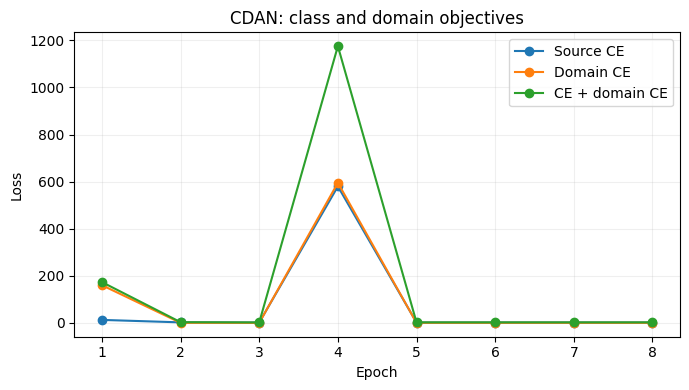

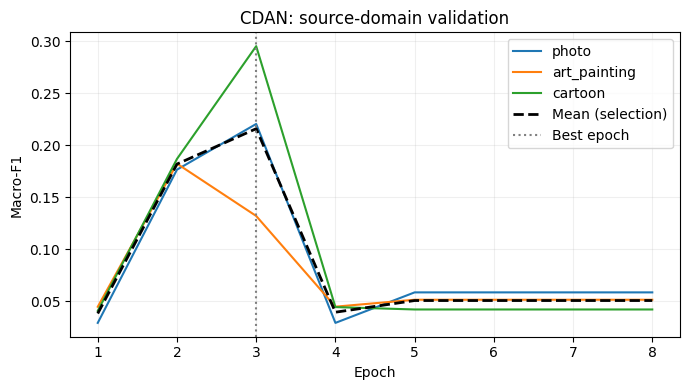

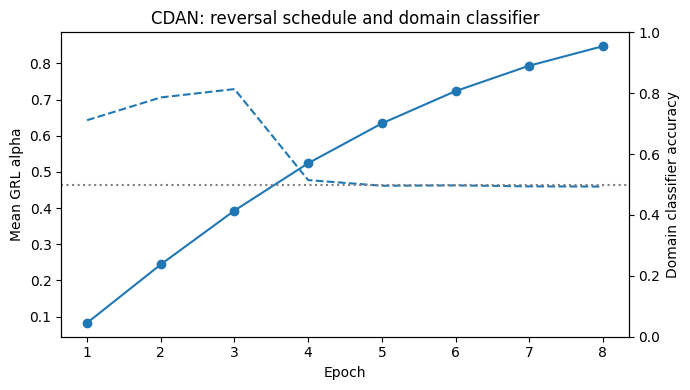

Pretrained BatchNorm buffers unchanged: 60


In [8]:
#! Save training curves, per-domain validation, GRL schedule and BN audit
history_df = pd.read_csv(RESULT_DIR / 'history.csv')
fig, ax = plt.subplots(figsize=(7, 4))

for column, label in [('train_cls_loss', 'Source CE'),
                      ('train_alignment_loss', 'Domain CE'),
                      ('train_total_loss', 'CE + domain CE')]:
    ax.plot(history_df['epoch'], history_df[column], marker='o', label=label)

ax.set(xlabel='Epoch', ylabel='Loss', title='CDAN: class and domain objectives')
ax.grid(alpha=0.2)
ax.legend()

fig.tight_layout()
fig.savefig(RESULT_DIR / 'cdan_training_losses.png', dpi=250)

plt.show()

fig, ax = plt.subplots(figsize=(7, 4))

for domain in SOURCE_DOMAINS:
    ax.plot(history_df['epoch'], history_df[f'val_{domain}_macro_f1'], label=domain)

ax.plot(history_df['epoch'], history_df['mean_source_val_macro_f1'],
        color='black', linestyle='--', linewidth=2, label='Mean (selection)')
ax.axvline(best_epoch, color='gray', linestyle=':', label='Best epoch')
ax.set(xlabel='Epoch', ylabel='Macro-F1', title='CDAN: source-domain validation')
ax.grid(alpha=0.2)
ax.legend()

fig.tight_layout()
fig.savefig(RESULT_DIR / 'cdan_source_macro_f1.png', dpi=250)

plt.show()

fig, ax1 = plt.subplots(figsize=(7, 4))

ax1.plot(history_df['epoch'], history_df['mean_grl_alpha'], marker='o', label='GRL strength')
ax1.set(xlabel='Epoch', ylabel='Mean GRL alpha', title='CDAN: reversal schedule and domain classifier')
ax2 = ax1.twinx()
ax2.plot(history_df['epoch'], history_df['mean_domain_accuracy'], linestyle='--', label='Domain acc')
ax2.axhline(0.5, linestyle=':', color='gray')
ax2.set(ylabel='Domain classifier accuracy', ylim=(0, 1))

fig.tight_layout()
fig.savefig(RESULT_DIR / 'cdan_domain_diagnostics.png', dpi=250)

plt.show()

#! Confirm the best checkpoint preserved every pretrained running statistic
best_state = model.state_dict()
bn_mismatches = [name for name, initial_tensor in BN_REFERENCE.items()
                 if not torch.equal(best_state[name].detach().cpu(), initial_tensor)]

if bn_mismatches:
    raise RuntimeError('ImageNet BatchNorm running statistics changed: ' + str(bn_mismatches[:5]))

bn_affine_trainable = all(layer.weight.requires_grad and layer.bias.requires_grad
                          for layer in model.modules()
                          if isinstance(layer, nn.modules.batchnorm._BatchNorm))

if not bn_affine_trainable:
    raise RuntimeError('BatchNorm affine parameters unexpectedly frozen')

(RESULT_DIR / 'batchnorm_audit.json').write_text(json.dumps({
    'running_stats_identical_to_initial': True,
    'checked_buffers': len(BN_REFERENCE), 'bn_affine_trainable': True,
}, indent=2))

print('Pretrained BatchNorm buffers unchanged:', len(BN_REFERENCE))

In [9]:
#! Final artifact verification (no additional model inference)
required = [ADAPTATION_FILE, CDAN_FILE, RUN_CONFIG_PATH, INITIAL_PATH,
            BEST_PATH, LAST_PATH, RESULT_DIR / 'history.csv',
            RESULT_DIR / 'source_validation.csv', RESULT_DIR / 'summary.json',
            RESULT_DIR / 'batchnorm_audit.json',
            RESULT_DIR / 'cdan_training_losses.png',
            RESULT_DIR / 'cdan_source_macro_f1.png',
            RESULT_DIR / 'cdan_domain_diagnostics.png']

missing = [str(path) for path in required if not path.is_file()]

if missing:
    raise FileNotFoundError('Missing CDAN artifacts: ' + str(missing))

saved_best = torch.load(BEST_PATH, map_location='cpu', weights_only=True)
saved_last = torch.load(LAST_PATH, map_location='cpu', weights_only=True)
saved_history = pd.read_csv(RESULT_DIR / 'history.csv')
saved_val = pd.read_csv(RESULT_DIR / 'source_validation.csv')

if not saved_last['finished'] or saved_best['epoch'] != best_epoch:
    raise RuntimeError('CDAN training incomplete or selected checkpoint disagrees')

if (len(saved_history) != saved_last['epoch']
        or saved_best['run_config_sha256'] != file_sha256(RUN_CONFIG_PATH)):
    raise RuntimeError('CDAN history or config mismatch')

if (not np.isclose(saved_val.loc[saved_val.domain == 'mean', 'macro_f1'].iloc[0],
                   saved_best['best_source_val_mean_macro_f1'], atol=1e-8)):
    raise RuntimeError('CDAN source metrics disagree with best saved checkpoint')

if 'discriminator_state_dict' not in saved_best or 'discriminator_state_dict' not in saved_last:
    raise RuntimeError('CDAN discriminator not checkpointed')

print('TASK 2D COMPLETE — CDAN')
print('Artifacts checked:', len(required))
print('Best epoch:', saved_best['epoch'])
print('Best mean source macro-F1:', round(saved_best['best_source_val_mean_macro_f1'], 4))
print('Best model:', BEST_PATH)
print('Target labels / target accuracy: not used.')

TASK 2D COMPLETE — CDAN
Artifacts checked: 13
Best epoch: 3
Best mean source macro-F1: 0.2158
Best model: /content/drive/MyDrive/pa1-beyond-iid/task2/models/cdan_best.pt
Target labels / target accuracy: not used.
